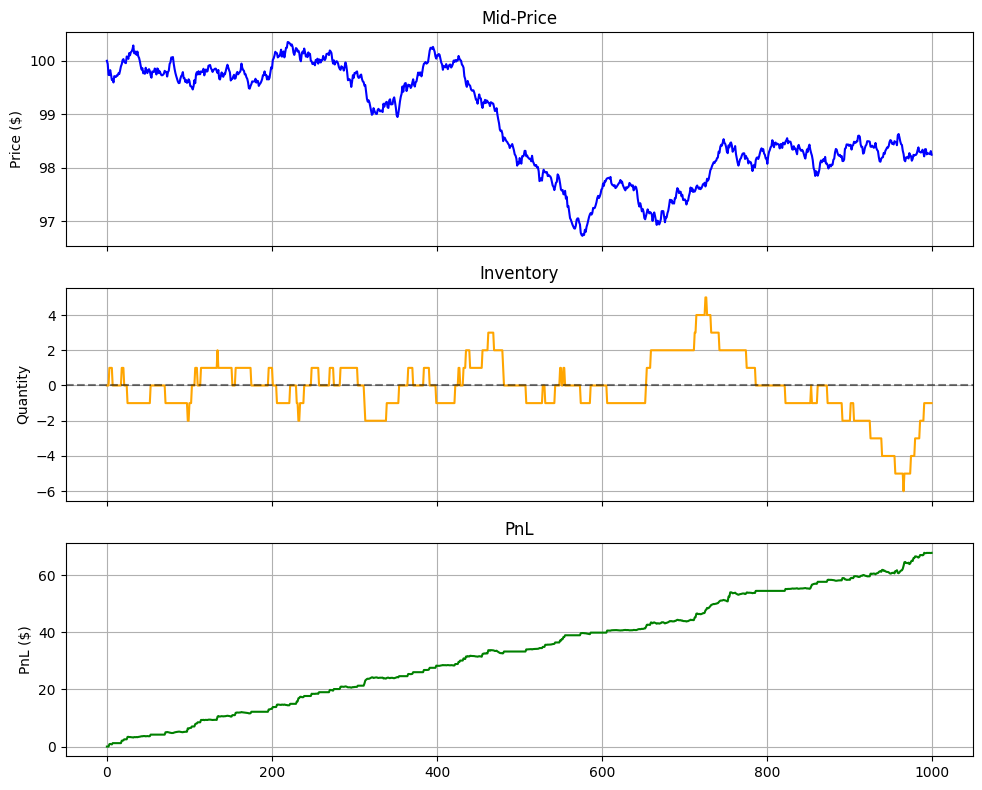

In [ ]:
import numpy as np
import math

#Initialization of the Stochastic Process
def generated_mid_price_path(S_0, volatility,T,N) : 
        dt = T/N
        dS = volatility * math.sqrt(dt)*np.random.normal(0,1, N)
        return S_0 + np.cumsum(np.insert(dS, 0, 0))

#Application of the Avellaneda Stoikov Model
class AvellanedaStoikovMM :

    def __init__(self, gamma, sigma, T, k):
        self.gamma = gamma
        self.sigma = sigma
        self.T = T
        self.k = k

    def reservation_price(self,s,q,t):
         r = s - q*self.gamma*self.sigma**2*(self.T-t)
         return r 
    
    def optimal_spread(self, t):
         delta = (self.gamma*(self.sigma)**2*(self.T - t))/2 + math.log(1 + (self.gamma/self.k))/self.gamma
         return delta
    
    def get_quotes(self,s,q,t) :
         r = self.reservation_price(s,q,t)
         delta = self.optimal_spread(t)
         bid = r - delta 
         ask = r + delta
         return bid, ask
    
#Condition to take the trade
def simulate_execution(delta, A, k, dt) : 
    P = A * math.exp(-k * delta)*dt
    random = np.random.uniform(0,1)
    if random < P :
        return True
    else :
        return False

#Simulation
def run_simulation(S_0, volatility, gamma, sigma, T, A, N, k):
    mid_price = generated_mid_price_path(S_0, volatility,T,N)
    dt = T/N

    mm = AvellanedaStoikovMM(gamma, sigma, T,k)
    q = 0
    cash = 0.0
    inventory_hist = []
    PnL_hist = []

    for i in range(N):
            s = mid_price[i]
            t = i*dt
            bid, ask = mm.get_quotes(s,q,t)
            d_bid = s - bid
            d_ask = ask - s

            if simulate_execution(d_bid, A, k, dt) :
                 q += 1
                 cash -= bid

            if simulate_execution(d_ask, A, k, dt) :
                 q -= 1
                 cash += ask

            PnL = cash + q*s
            inventory_hist.append(q)
            PnL_hist.append(PnL)

    return mid_price, inventory_hist, PnL_hist
                 
import matplotlib.pyplot as plt

#Start Example
prices, inventory, PnL = run_simulation(
    S_0=100.0, 
    volatility=2.0, 
    gamma=0.1, 
    sigma=2.0, 
    T=1.0,  
    A=140.0, 
    N=1000, 
    k=1.5
)

#Visualization
fig, axs = plt.subplots(3, 1, figsize=(10, 8), sharex=True)

axs[0].plot(prices[:-1], color='blue', label='Mid Price ($S_t$)')
axs[0].set_title("Mid-Price")
axs[0].set_ylabel("Price ($)")
axs[0].grid(True)

axs[1].plot(inventory, color='orange', label='Inventory ($q$)')
axs[1].axhline(0, color='black', linestyle='--', alpha=0.5)
axs[1].set_title("Inventory")
axs[1].set_ylabel("Quantity")
axs[1].grid(True)

axs[2].plot(PnL, color='green', label='PnL ($)')
axs[2].set_title("PnL")
axs[2].set_ylabel("PnL ($)")
axs[2].grid(True)

plt.tight_layout()
plt.show()
         




         

